In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np

from JacobianODE.jacobians.metrics import mase

In [11]:
latent_run_id = 'xu6q1wzm'
vanilla_run_id = 'yo7rgymq'

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_run, load_checkpoint, normalize_data, create_dataloaders,
)
from JacobianODE.jacobians.metrics import mase

WANDB_ENTITY = "JacobianODE"
SAVE_DIR = None  # uses cfg.training.logger.save_dir from each run
PREDICTION_STEPS = 10
N_VAL_BATCHES = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
# Auto-discover which wandb project each run belongs to
api = wandb.Api()

def find_run_project(entity, run_id):
    """Search for a run across all projects in a wandb entity."""
    for project in api.projects(entity):
        try:
            api.run(f"{entity}/{project.name}/{run_id}")
            return f"{entity}/{project.name}"
        except Exception:
            continue
    raise ValueError(f"Run {run_id} not found in entity {entity}")

print(f"Finding project for latent_run_id={latent_run_id}...")
latent_project_path = find_run_project(WANDB_ENTITY, latent_run_id)
print(f"  -> {latent_project_path}")

print(f"\nFinding project for vanilla_run_id={vanilla_run_id}...")
vanilla_project_path = find_run_project(WANDB_ENTITY, vanilla_run_id)
print(f"  -> {vanilla_project_path}")

Finding project for latent_run_id=xu6q1wzm...
  -> JacobianODE/LorenzLatent_FS_LPL_BIG_JacobianODE

Finding project for vanilla_run_id=yo7rgymq...
  -> JacobianODE/LorenzCustom__JacobianODE


In [14]:
# Load latent model (trained on normalized Lorenz)
print("=" * 60)
print(f"Loading latent model  [{latent_run_id}]")
print("=" * 60)
(latent_run, latent_cfg, _, latent_dt,
 latent_values_raw, _, latent_val_dl_raw, _, _, latent_model) = load_run(
    latent_project_path, run_id=latent_run_id, save_dir=SAVE_DIR, verbose=True,
)
# Normalize data to match training conditions
if latent_cfg.data.postprocessing.normalize:
    latent_values, _, _ = normalize_data(latent_values_raw)
    _, latent_val_dl, _, _ = create_dataloaders(latent_cfg, latent_values)
else:
    latent_val_dl = latent_val_dl_raw

load_checkpoint(latent_run, latent_cfg, latent_model, save_dir=SAVE_DIR, verbose=True)
latent_model.prediction_steps = PREDICTION_STEPS
latent_model.eval()
latent_model = latent_model.to(device)
print(f"\nLatent model ready | prediction_steps={latent_model.prediction_steps}")

# Load vanilla model (trained on unnormalized Lorenz)
print("\n" + "=" * 60)
print(f"Loading vanilla model [{vanilla_run_id}]")
print("=" * 60)
(vanilla_run, vanilla_cfg, _, vanilla_dt,
 vanilla_values_raw, _, vanilla_val_dl_raw, _, _, vanilla_model) = load_run(
    vanilla_project_path, run_id=vanilla_run_id, save_dir=SAVE_DIR, verbose=True,
)
if vanilla_cfg.data.postprocessing.normalize:
    vanilla_values, _, _ = normalize_data(vanilla_values_raw)
    _, vanilla_val_dl, _, _ = create_dataloaders(vanilla_cfg, vanilla_values)
else:
    vanilla_val_dl = vanilla_val_dl_raw

load_checkpoint(vanilla_run, vanilla_cfg, vanilla_model, save_dir=SAVE_DIR, verbose=True)
vanilla_model.eval()
vanilla_model = vanilla_model.to(device)

# For 10-step prediction: crop batches to traj_init_steps + PREDICTION_STEPS
vanilla_traj_init_steps = vanilla_model.jacobianODEint_kwargs.get('traj_init_steps', 2)
vanilla_crop_len = vanilla_traj_init_steps + PREDICTION_STEPS
print(f"\nVanilla model ready | traj_init_steps={vanilla_traj_init_steps}, crop_len={vanilla_crop_len}")

Loading latent model  [xu6q1wzm]

Latent model ready | prediction_steps=10

Loading vanilla model [yo7rgymq]

Vanilla model ready | traj_init_steps=15, crop_len=25


In [15]:
# Run 10-step predictions with alpha_teacher_forcing=0 on N_VAL_BATCHES validation batches

def collect_mase_scores(model, val_dl, n_batches, crop_len=None):
    """
    Iterate val_dl, call trajectory_model_step with alpha_teacher_forcing=0,
    and collect per-batch MASE scores.

    crop_len: if set, crop each batch to (B, crop_len, D) before the step.
              Used to enforce a fixed prediction horizon for vanilla models.
    """
    mase_scores = []
    batch_iter = iter(val_dl)
    with torch.no_grad():
        for _ in tqdm(range(n_batches), desc=model.__class__.__name__):
            try:
                batch = next(batch_iter)
            except StopIteration:
                break
            batch = batch.to(device)
            if crop_len is not None:
                batch = batch[:, :crop_len, :]
            ret = model.trajectory_model_step(
                batch,
                alpha_teacher_forcing=0.0,
                obs_noise_scale=0.0,
            )
            mase_scores.append(ret['metric_vals']['mase'].item())
    return np.array(mase_scores)


print(f"Collecting {N_VAL_BATCHES} batches — latent model (prediction_steps={PREDICTION_STEPS})...")
latent_mase = collect_mase_scores(latent_model, latent_val_dl, N_VAL_BATCHES)

print(f"\nCollecting {N_VAL_BATCHES} batches — vanilla model (crop_len={vanilla_crop_len})...")
vanilla_mase = collect_mase_scores(vanilla_model, vanilla_val_dl, N_VAL_BATCHES, crop_len=vanilla_crop_len)

print(f"\nLatent  — n={len(latent_mase)}, mean={latent_mase.mean():.4f}, median={np.median(latent_mase):.4f}, std={latent_mase.std():.4f}")
print(f"Vanilla — n={len(vanilla_mase)}, mean={vanilla_mase.mean():.4f}, median={np.median(vanilla_mase):.4f}, std={vanilla_mase.std():.4f}")

LitLatentJacobianODE:   0%|          | 0/100 [00:00<?, ?it/s]

LitMLP:   0%|          | 0/100 [00:00<?, ?it/s]


Latent  — n=100, mean=0.8967, median=0.9069, std=0.0720
Vanilla — n=100, mean=0.0445, median=0.0242, std=0.0364


Model                          run_id           mean   median      std    %>1.0
----------------------------------------------------------------------------
Latent JacobianODE (normalized) xu6q1wzm       0.8967   0.9069   0.0720     0.0%
Vanilla JacobianODE (unnormalized) yo7rgymq       0.0445   0.0242   0.0364     0.0%


/tmp/ipykernel_139228/3910994462.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False,


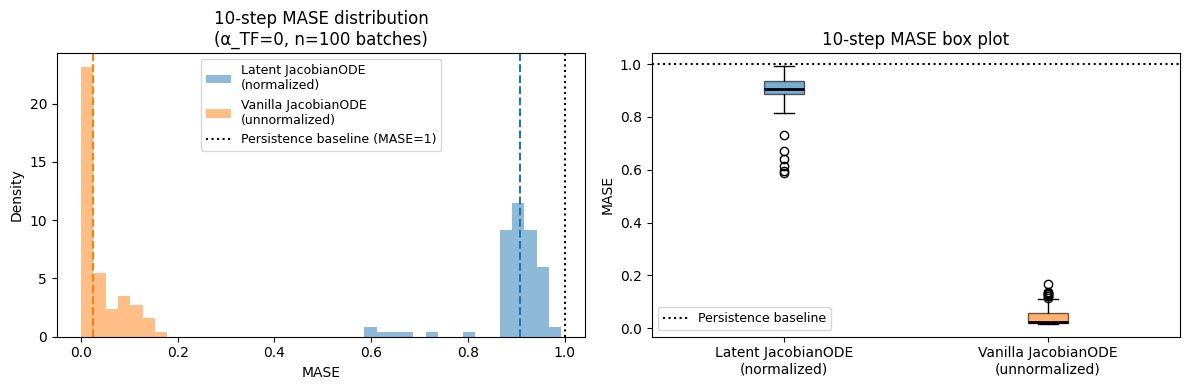

In [16]:
# Compare MASE distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels  = ['Latent JacobianODE\n(normalized)', 'Vanilla JacobianODE\n(unnormalized)']
colors  = ['tab:blue', 'tab:orange']
data    = [latent_mase, vanilla_mase]
run_ids = [latent_run_id, vanilla_run_id]

# --- Panel 1: overlapping histograms / KDE ---
ax = axes[0]
bins = np.linspace(0, max(np.percentile(latent_mase, 99), np.percentile(vanilla_mase, 99)), 40)
for d, lbl, c in zip(data, labels, colors):
    ax.hist(d, bins=bins, alpha=0.5, color=c, label=lbl, density=True)
    ax.axvline(np.median(d), color=c, linestyle='--', linewidth=1.5)
ax.axvline(1.0, color='k', linestyle=':', linewidth=1.5, label='Persistence baseline (MASE=1)')
ax.set_xlabel('MASE')
ax.set_ylabel('Density')
ax.set_title(f'{PREDICTION_STEPS}-step MASE distribution\n(α_TF=0, n={N_VAL_BATCHES} batches)')
ax.legend(fontsize=9)

# --- Panel 2: box plots ---
ax = axes[1]
bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.axhline(1.0, color='k', linestyle=':', linewidth=1.5, label='Persistence baseline')
ax.set_ylabel('MASE')
ax.set_title(f'{PREDICTION_STEPS}-step MASE box plot')
ax.legend(fontsize=9)

# Print summary table
print(f"{'Model':<30} {'run_id':<12} {'mean':>8} {'median':>8} {'std':>8} {'%>1.0':>8}")
print("-" * 76)
for d, lbl, rid in zip(data, labels, run_ids):
    print(f"{lbl.replace(chr(10),' '):<30} {rid:<12} {d.mean():8.4f} {np.median(d):8.4f} {d.std():8.4f} {(d > 1.0).mean()*100:7.1f}%")

plt.tight_layout()
plt.show()